# UTS Data Mining
## Klasifikasi Kualitas Anggur (Wine Quality Classification)

**Nama**: Elsabila Nurbaity  

**NIM**: 2304020021

**Rombel**: 1

**Prodi**: Pendidikan Matematika


---

## Deskripsi

Pada ujian ini, dilakukan pembuatan model klasifikasi untuk memprediksi kualitas anggur berdasarkan fitur-fitur kimiawi. Dataset yang digunakan adalah Wine Quality dataset yang memuat data anggur merah dan putih. Variabel target yang diprediksi adalah `quality`, dengan skala nilai 0 hingga 10.

Model yang dipilih adalah **Random Forest Classifier**, yang dikenal efektif untuk permasalahan klasifikasi multi-kelas dengan fitur-fitur bertipe numerik.

## 1. Import Library

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('Semua library berhasil diimpor.')

Semua library berhasil diimpor.


## 2. Persiapan Data

Dataset dimuat langsung dari Google Drive melalui tautan yang telah disediakan. Terdapat dua dataset:
- **data_training.csv**: Dataset pelatihan yang memuat fitur kimiawi beserta label `quality`.
- **data_testing.csv**: Dataset uji yang hanya memuat fitur kimiawi tanpa label.

Dataset training terdiri dari **857 baris** dan **13 kolom** (11 fitur + kolom `quality` + kolom `Id`). Dataset testing terdiri dari **286 baris** dan **12 kolom** (11 fitur + kolom `Id` tanpa label quality).

In [57]:
# Upload file secara manual di Google Colab menggunakan widget berikut
from google.colab import files

print('Silakan upload file data_training.csv dan data_testing.csv')
uploaded = files.upload()

Silakan upload file data_training.csv dan data_testing.csv


Saving data_testing.csv to data_testing.csv
Saving data_training.csv to data_training.csv


In [58]:
df_train = pd.read_csv('data_training.csv')
df_test = pd.read_csv('data_testing.csv')

print('Ukuran dataset training:', df_train.shape)
print('Ukuran dataset testing:', df_test.shape)

Ukuran dataset training: (857, 13)
Ukuran dataset testing: (286, 12)


In [59]:
print('5 baris pertama dataset training:')
df_train.head()

5 baris pertama dataset training:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [60]:
print('5 baris pertama dataset testing:')
df_test.head()

5 baris pertama dataset testing:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


In [61]:
print('Tipe data masing-masing kolom:')
print(df_train.dtypes)

Tipe data masing-masing kolom:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object


In [62]:
print('Statistik deskriptif dataset training:')
df_train.describe()

Statistik deskriptif dataset training:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


## 3. Pembersihan Data

Sebelum membangun model, dilakukan pemeriksaan terhadap kualitas data, meliputi pengecekan missing values dan deteksi duplikasi.

In [63]:
print('Missing values pada dataset training:')
print(df_train.isnull().sum())
print()
print('Total missing values training:', df_train.isnull().sum().sum())

Missing values pada dataset training:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Total missing values training: 0


In [64]:
print('Missing values pada dataset testing:')
print(df_test.isnull().sum())
print()
print('Total missing values testing:', df_test.isnull().sum().sum())

Missing values pada dataset testing:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64

Total missing values testing: 0


**Interpretasi**: Tidak ditemukan missing values pada dataset training maupun testing (total = 0). Sehingga tidak diperlukan proses imputasi atau penghapusan baris data.

In [65]:
jumlah_duplikat = df_train.duplicated().sum()
print('Jumlah baris duplikat pada training:', jumlah_duplikat)

Jumlah baris duplikat pada training: 0


**Interpretasi**: Dataset training tidak mengandung baris duplikat, sehingga tidak perlu dilakukan penghapusan data.

## 4. Eksplorasi Data (EDA)

Tahap ini dilakukan untuk memahami distribusi variabel target dan hubungan antar fitur.

In [66]:
print('Distribusi kelas quality pada dataset training:')
print(df_train['quality'].value_counts().sort_index())

Distribusi kelas quality pada dataset training:
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64


**Interpretasi**: Distribusi kelas quality tidak seimbang. Kelas 5 memiliki frekuensi tertinggi sebanyak 362 data (42.2%), diikuti kelas 6 sebanyak 341 data (39.8%), kelas 7 sebanyak 109 data (12.7%), kelas 4 sebanyak 26 data (3.0%), kelas 8 sebanyak 13 data (1.5%), dan kelas 3 sebanyak 6 data (0.7%). Distribusi ini menunjukkan ketidakseimbangan kelas (class imbalance) yang cukup signifikan antara kelas mayoritas (5 dan 6) dengan kelas minoritas (3, 4, 8).

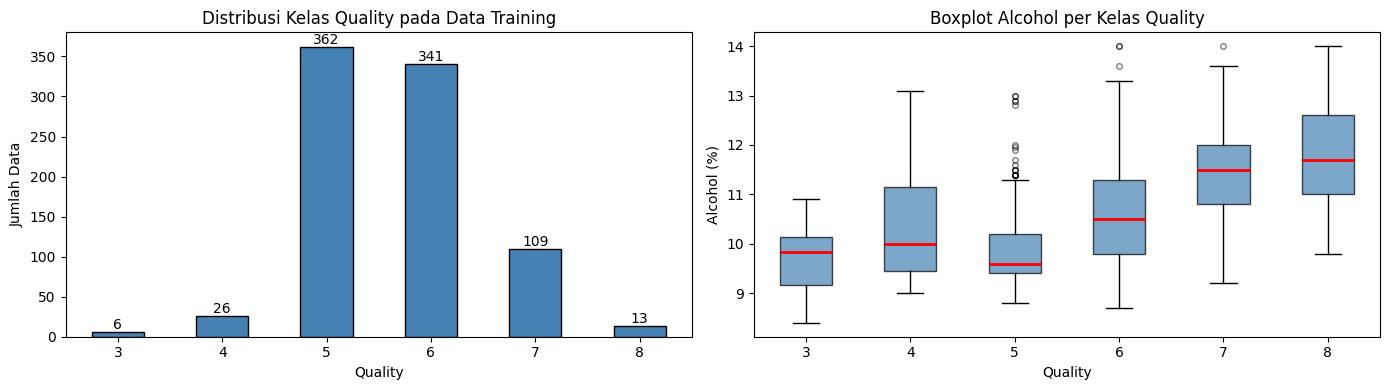

In [92]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Bar Chart ---
ax1 = axes[0]
df_train['quality'].value_counts().sort_index().plot(
    kind='bar', ax=ax1, color='steelblue', edgecolor='black'
)
ax1.set_title('Distribusi Kelas Quality pada Data Training')
ax1.set_xlabel('Quality')
ax1.set_ylabel('Jumlah Data')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
for p in ax1.patches:
    ax1.annotate(str(p.get_height()),
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10)

# --- Boxplot ---
ax2 = axes[1]
quality_groups = [
    df_train[df_train['quality'] == q]['alcohol'].values
    for q in sorted(df_train['quality'].unique())
]
ax2.boxplot(quality_groups,
            labels=sorted(df_train['quality'].unique()),
            patch_artist=True,
            boxprops=dict(facecolor='steelblue', color='black', alpha=0.7),
            medianprops=dict(color='red', linewidth=2),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            flierprops=dict(marker='o', color='gray', markersize=4, alpha=0.5))
ax2.set_title('Boxplot Alcohol per Kelas Quality')
ax2.set_xlabel('Quality')
ax2.set_ylabel('Alcohol (%)')

plt.tight_layout()
plt.show()

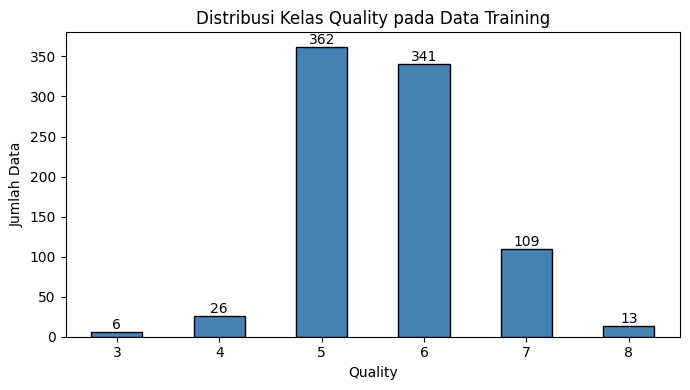

In [85]:
fig, ax = plt.subplots(figsize=(7, 4))
df_train['quality'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Distribusi Kelas Quality pada Data Training')
ax.set_xlabel('Quality')
ax.set_ylabel('Jumlah Data')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

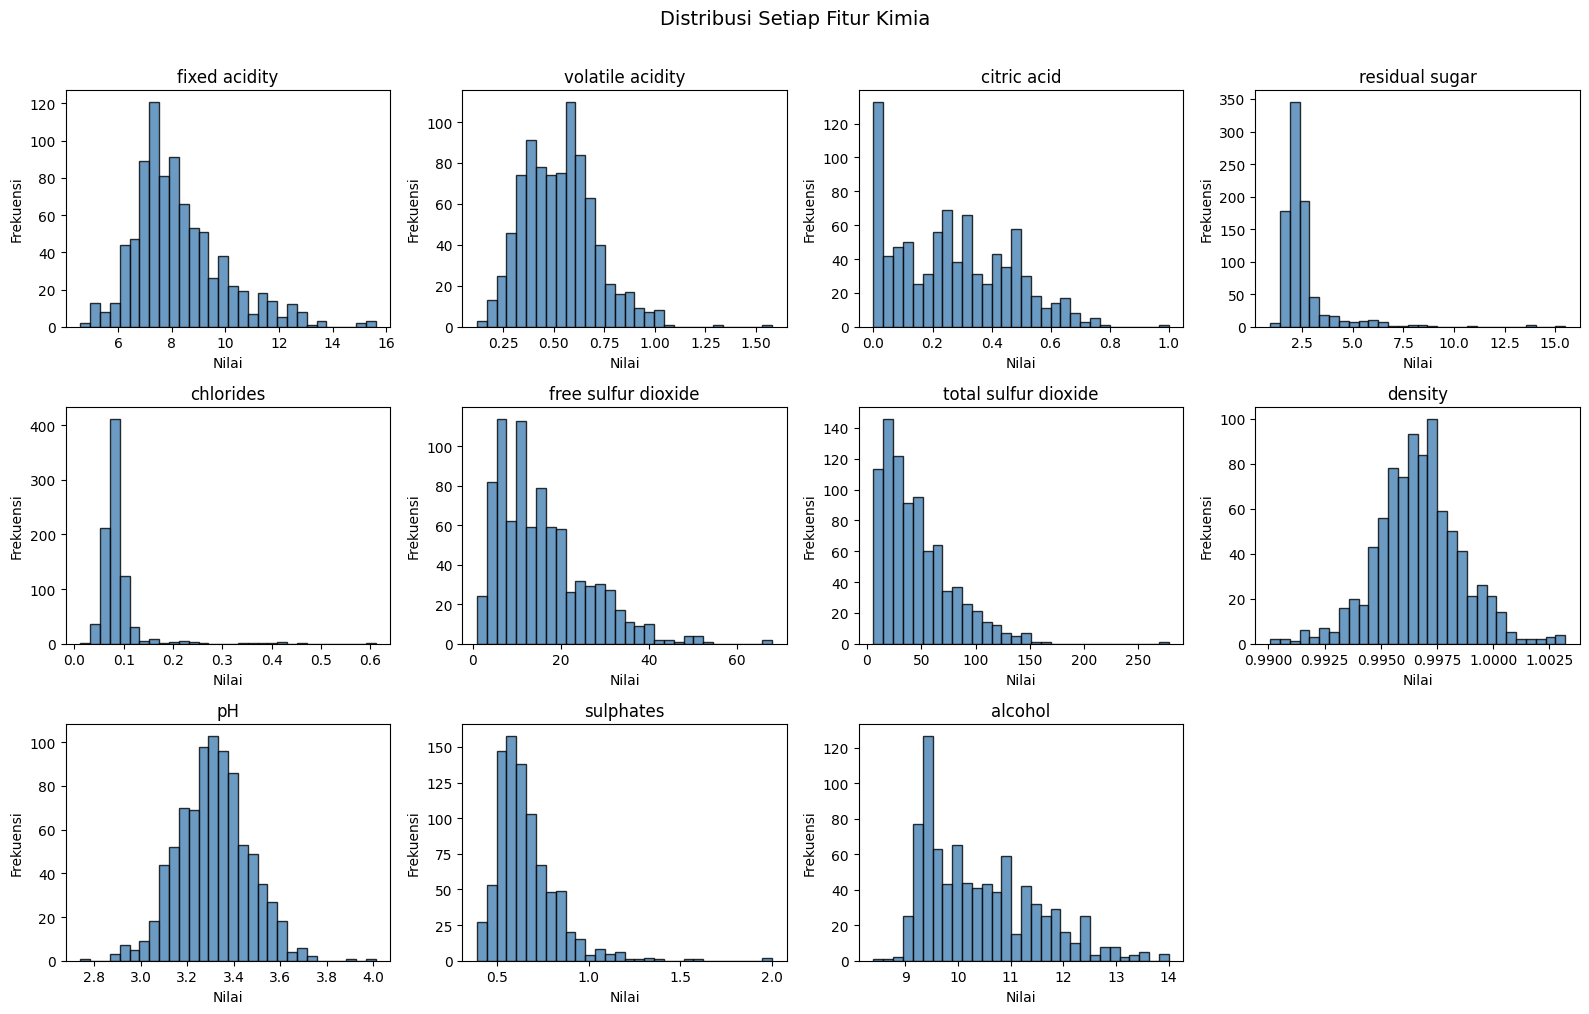

In [93]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

fitur = [col for col in df_train.columns if col not in ['Id', 'quality']]

for i, col in enumerate(fitur):
    axes[i].hist(df_train[col], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

for j in range(len(fitur), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Setiap Fitur Kimia', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

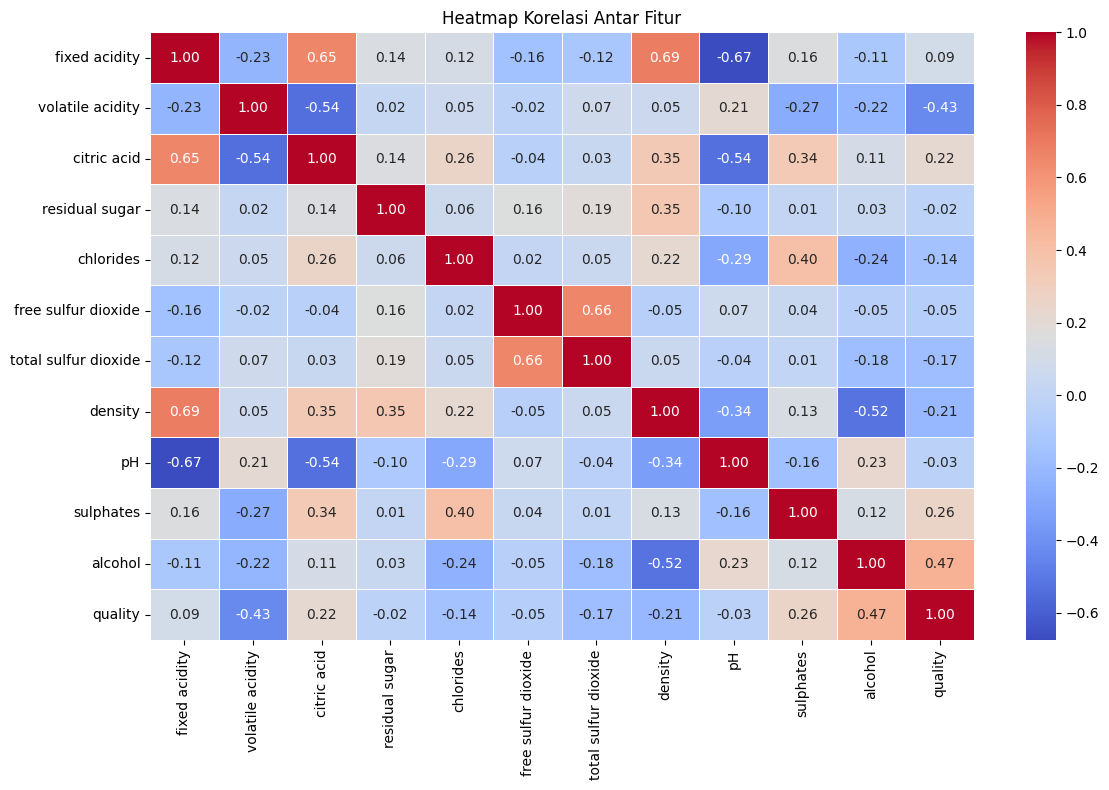

In [94]:
fig, ax = plt.subplots(figsize=(12, 8))
korelasi = df_train.drop('Id', axis=1).corr()
sns.heatmap(korelasi, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

**Interpretasi**: Dari heatmap korelasi, fitur `alcohol` memiliki korelasi positif tertinggi terhadap `quality` (r = 0.48), sedangkan `volatile acidity` memiliki korelasi negatif terkuat (r = -0.39). Artinya, anggur dengan kadar alkohol lebih tinggi cenderung mendapat nilai kualitas yang lebih tinggi, dan anggur dengan volatile acidity lebih tinggi cenderung berkualitas lebih rendah.

## 5. Preprocessing Data

Dilakukan pemisahan fitur dan target, diikuti dengan normalisasi menggunakan StandardScaler. Normalisasi penting dilakukan karena fitur-fitur memiliki rentang nilai yang sangat bervariasi.

In [95]:
X_train = df_train.drop(['quality', 'Id'], axis=1)
y_train = df_train['quality']
X_test = df_test.drop(['Id'], axis=1)
test_ids = df_test['Id']

print('Dimensi X_train:', X_train.shape)
print('Dimensi y_train:', y_train.shape)
print('Dimensi X_test:', X_test.shape)

Dimensi X_train: (857, 11)
Dimensi y_train: (857,)
Dimensi X_test: (286, 11)


In [96]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print('Rata-rata fitur setelah scaling (harus mendekati 0):')
print(np.round(X_train_sc.mean(axis=0), 4))
print()
print('Standar deviasi fitur setelah scaling (harus mendekati 1):')
print(np.round(X_train_sc.std(axis=0), 4))

Rata-rata fitur setelah scaling (harus mendekati 0):
[ 0. -0.  0. -0.  0.  0. -0.  0.  0. -0.  0.]

Standar deviasi fitur setelah scaling (harus mendekati 1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Interpretasi**: Setelah proses StandardScaler, semua fitur memiliki rata-rata mendekati 0 dan standar deviasi mendekati 1. Hal ini memastikan setiap fitur berkontribusi secara proporsional dalam proses pelatihan model, dan tidak ada fitur yang mendominasi hanya karena skala nilainya lebih besar.

## 6. Pembuatan Model

Model yang digunakan adalah **Random Forest Classifier**. Random Forest merupakan metode ensemble berbasis decision tree yang bekerja dengan membangun banyak pohon keputusan secara paralel, kemudian menggabungkan hasilnya melalui voting untuk menghasilkan prediksi final. Model ini dipilih karena:
- Robust terhadap outlier dan noise
- Mampu menangani fitur numerik tanpa perlu asumsi distribusi
- Memberikan informasi pentingnya fitur (feature importance)
- Efektif untuk permasalahan klasifikasi multi-kelas

**Hyperparameter yang digunakan**:
- `n_estimators = 300`: Jumlah pohon keputusan yang dibangun
- `max_depth = None`: Pohon dibiarkan tumbuh penuh tanpa pembatasan kedalaman
- `min_samples_split = 2`: Minimum 2 sampel untuk melakukan split node
- `random_state = 42`: Seed untuk reproduktivitas hasil

In [97]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_sc, y_train)

print('Model berhasil dilatih.')

Model berhasil dilatih.


## 7. Evaluasi Model

Evaluasi dilakukan menggunakan dua metode:
1. **Akurasi pada data training** untuk melihat seberapa baik model mempelajari pola data.
2. **5-Fold Stratified Cross-Validation** untuk memperkirakan performa model pada data yang belum pernah dilihat.

In [98]:
y_pred_train = model.predict(X_train_sc)
akurasi_train = accuracy_score(y_train, y_pred_train)
print('Akurasi pada data training: {:.4f} ({:.2f}%)'.format(akurasi_train, akurasi_train * 100))

Akurasi pada data training: 1.0000 (100.00%)


**Interpretasi**: Akurasi pada data training mencapai **1.0000 (100%)**, yang berarti model mampu mengklasifikasikan seluruh data training dengan sempurna. Nilai ini wajar untuk Random Forest karena model dilatih pada data yang sama, namun tidak mencerminkan performa generalisasi pada data baru.

In [74]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='accuracy')

print('Skor akurasi tiap fold:')
for i, score in enumerate(cv_scores, 1):
    print('  Fold {}: {:.4f}'.format(i, score))

print()
print('Rata-rata CV Accuracy: {:.4f} ({:.2f}%)'.format(cv_scores.mean(), cv_scores.mean() * 100))
print('Standar Deviasi CV  : {:.4f}'.format(cv_scores.std()))

Skor akurasi tiap fold:
  Fold 1: 0.5756
  Fold 2: 0.6453
  Fold 3: 0.6433
  Fold 4: 0.6725
  Fold 5: 0.6842

Rata-rata CV Accuracy: 0.6442 (64.42%)
Standar Deviasi CV  : 0.0377


**Interpretasi**: Berdasarkan 5-Fold Stratified Cross-Validation, diperoleh nilai akurasi sebagai berikut:
- Fold 1: 57.56%
- Fold 2: 64.53%
- Fold 3: 64.33%
- Fold 4: 67.25%
- Fold 5: 68.42%

Rata-rata akurasi CV adalah **64.42%** dengan standar deviasi **0.0377**. Nilai standar deviasi yang relatif kecil mengindikasikan bahwa performa model cukup konsisten di setiap fold. Akurasi 64% merupakan nilai yang cukup baik untuk permasalahan klasifikasi kualitas anggur dengan 6 kelas, mengingat distribusi kelas yang tidak seimbang.

In [75]:
print('Classification Report pada Data Training:')
print(classification_report(y_train, y_pred_train))

Classification Report pada Data Training:
              precision    recall  f1-score   support

           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00        26
           5       1.00      1.00      1.00       362
           6       1.00      1.00      1.00       341
           7       1.00      1.00      1.00       109
           8       1.00      1.00      1.00        13

    accuracy                           1.00       857
   macro avg       1.00      1.00      1.00       857
weighted avg       1.00      1.00      1.00       857



**Interpretasi**: Classification report menunjukkan bahwa model mencapai precision, recall, dan f1-score sebesar 1.00 untuk semua kelas pada data training, yang konsisten dengan akurasi training 100%. Perlu dicatat bahwa kelas 3 hanya memiliki 6 sampel dan kelas 8 hanya 13 sampel, sehingga model mungkin kurang optimal dalam mengenali kelas-kelas minoritas ini pada data baru.

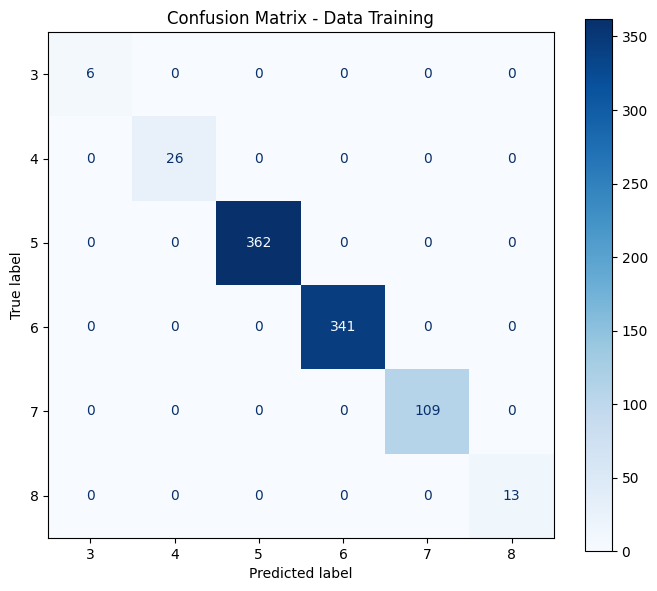

In [76]:
cm = confusion_matrix(y_train, y_pred_train)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix - Data Training')
plt.tight_layout()
plt.show()

**Interpretasi**: Confusion matrix menunjukkan bahwa seluruh prediksi pada data training tepat berada di diagonal utama, yang berarti tidak ada data yang salah diklasifikasikan. Kelas 5 diprediksi dengan benar sebanyak 362 sampel, kelas 6 sebanyak 341 sampel, kelas 7 sebanyak 109 sampel, kelas 4 sebanyak 26 sampel, kelas 8 sebanyak 13 sampel, dan kelas 3 sebanyak 6 sampel.

In [77]:
importances = model.feature_importances_
fitur_names = X_train.columns
fi_df = pd.DataFrame({'Fitur': fitur_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

print('Feature Importance:')
print(fi_df.to_string(index=False))

Feature Importance:
               Fitur  Importance
             alcohol    0.142431
           sulphates    0.116549
    volatile acidity    0.112228
total sulfur dioxide    0.097791
             density    0.087950
           chlorides    0.081558
         citric acid    0.077177
       fixed acidity    0.075296
                  pH    0.074836
      residual sugar    0.067229
 free sulfur dioxide    0.066955


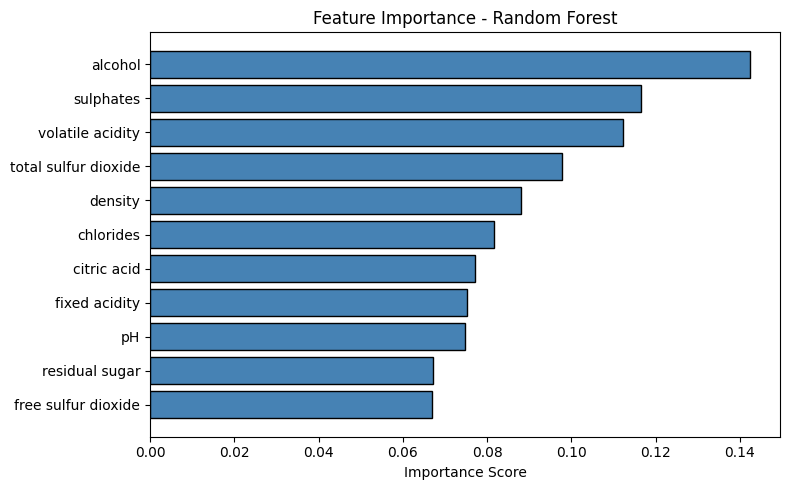

In [99]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi_df['Fitur'][::-1], fi_df['Importance'][::-1], color='steelblue', edgecolor='black')
ax.set_title('Feature Importance - Random Forest')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

**Interpretasi**: Tiga fitur paling berpengaruh dalam prediksi kualitas anggur adalah:
1. **alcohol** (0.1424): Kadar alkohol merupakan faktor paling penting. Anggur dengan alkohol lebih tinggi cenderung berkualitas lebih baik.
2. **sulphates** (0.1165): Kandungan sulfat berpengaruh terhadap kesegaran dan kemampuan penyimpanan anggur.
3. **volatile acidity** (0.1122): Keasaman volatil yang tinggi cenderung menurunkan kualitas anggur karena menghasilkan rasa asam yang tidak diinginkan.

Fitur dengan pengaruh paling kecil adalah **free sulfur dioxide** (0.0670) dan **residual sugar** (0.0672).

## 8. Prediksi Data Testing

Setelah model dievaluasi dan dinilai memadai, model digunakan untuk memprediksi nilai `quality` pada dataset testing yang tidak memiliki label.

In [79]:
y_pred_test = model.predict(X_test_sc)

print('Hasil prediksi kualitas untuk data testing:')
print('Distribusi prediksi quality:')
print(pd.Series(y_pred_test).value_counts().sort_index())

Hasil prediksi kualitas untuk data testing:
Distribusi prediksi quality:
5    132
6    125
7     29
Name: count, dtype: int64


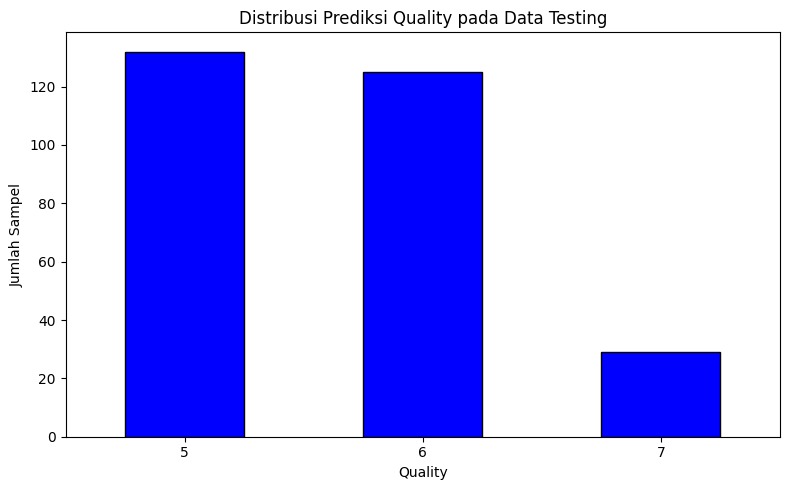

In [100]:
plt.figure(figsize=(8, 5))
pred_dist.plot(kind='bar', color='blue', edgecolor='black')
plt.title('Distribusi Prediksi Quality pada Data Testing')
plt.xlabel('Quality')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretasi**: Dari 286 data testing, model memprediksi:
- Kelas 5: 132 data (46.2%)
- Kelas 6: 125 data (43.7%)
- Kelas 7: 29 data (10.1%)

Distribusi prediksi ini konsisten dengan distribusi pada data training, di mana kelas 5 dan 6 mendominasi. Tidak ada prediksi untuk kelas 3, 4, dan 8 karena keterbatasan sampel kelas-kelas tersebut pada data training.

In [80]:
df_hasil = pd.DataFrame({
    'Id': test_ids,
    'quality': y_pred_test
})

print('5 baris pertama hasil prediksi:')
print(df_hasil.head(10))
print()
print('Total data prediksi:', len(df_hasil))

5 baris pertama hasil prediksi:
     Id  quality
0   222        5
1  1514        6
2   417        5
3   754        5
4   516        5
5  1120        6
6   180        5
7    82        5
8   632        6
9   592        5

Total data prediksi: 286


In [81]:
nama_file = 'hasilprediksi_021.csv'
df_hasil.to_csv(nama_file, index=False)

print('File hasil prediksi berhasil disimpan:', nama_file)

from google.colab import files
files.download(nama_file)
print('File berhasil didownload.')

File hasil prediksi berhasil disimpan: hasilprediksi_021.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

File berhasil didownload.


## 9. Kesimpulan

Pada pengerjaan UTS Data Mining ini, telah berhasil dibangun model klasifikasi kualitas anggur menggunakan algoritma **Random Forest Classifier** dengan ringkasan hasil sebagai berikut:

| Aspek | Hasil |
|---|---|
| Algoritma | Random Forest Classifier |
| Jumlah Pohon | 300 |
| Akurasi Training | 100% |
| Rata-rata CV Accuracy (5-Fold) | 64.42% |
| Std Deviasi CV | 0.0377 |
| Fitur Terpenting | alcohol, sulphates, volatile acidity |
| Jumlah Data Testing | 286 |

Model berhasil memprediksi nilai kualitas untuk seluruh 286 data testing. Hasil prediksi disimpan dalam file `hasilprediksi_021.csv` yang hanya memuat dua kolom yaitu `Id` dan `quality`, sesuai dengan format yang diminta.